In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
DATA_PATH = '/kaggle/input/datasets/pratyushakar/rossmann-store-sales'

train = pd.read_csv(f'{DATA_PATH}/train.csv', low_memory=False, parse_dates=['Date'])
store = pd.read_csv(f'{DATA_PATH}/store.csv')

print(f'Train shape : {train.shape}')
print(f'Store shape : {store.shape}')
train.head()

Train shape : (1017209, 9)
Store shape : (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
print('=== Train — dtypes ===')
print(train.dtypes)
print()
print('=== Train — Missing values ===')
print(train.isnull().sum())
print()
print('=== Store — Missing values ===')
print(store.isnull().sum())

=== Train — dtypes ===
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

=== Train — Missing values ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

=== Store — Missing values ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


Структура даних: Навчальний набір містить 1 017 209 щоденних записів з 1115 магазинів без пропущених значень. У store.csv поля часу змагань (CompetitionOpenSinceMonth/Year) відсутні для 354 магазинів, а стовпці, пов'язані з Promo2, відсутні для 544 — обидва питання будуть вирішені під час генерації ознак.


In [4]:
# Check for duplicates
duplicates = train.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')


Number of duplicate rows: 0


In [5]:
duplicates = store.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


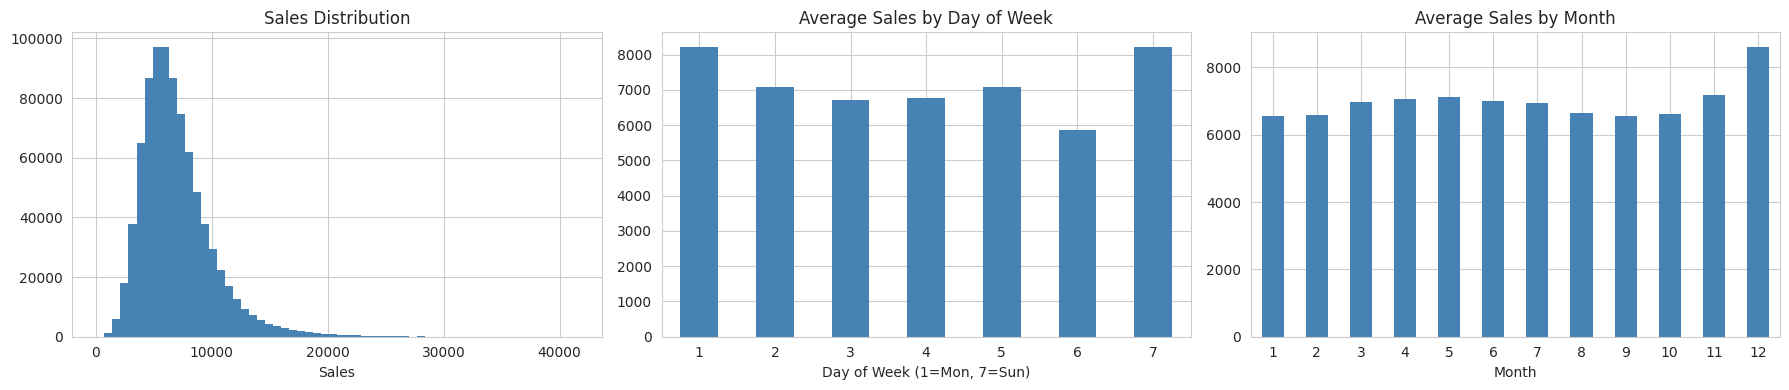


Sales descriptive statistics (open stores only):
count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [6]:
open_train = train[(train['Open'] == 1) & (train['Sales'] > 0)].copy()
open_train['Month'] = open_train['Date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

open_train['Sales'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')

open_train.groupby('DayOfWeek')['Sales'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='none'
)
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day of Week (1=Mon, 7=Sun)')
axes[1].tick_params(axis='x', rotation=0)

open_train.groupby('Month')['Sales'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='none'
)
axes[2].set_title('Average Sales by Month')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nSales descriptive statistics (open stores only):')
print(open_train['Sales'].describe())

Розподіл з правостороннім зміщенням та сильними тижневими та сезонними закономірностями. Середньодобові продажі на магазин становлять €6956, тоді як медіана нижча – €6369 – правий хвіст, зумовлений високими обсягами, що досягають €41 551, піднімає середнє значення вгору. Понеділок постійно фіксує найнижчі продажі; обсяг стабільно зростає до четверга. Грудень є піковим місяцем, що підтверджує, що календарні особливості матимуть значну прогностичну вагу.

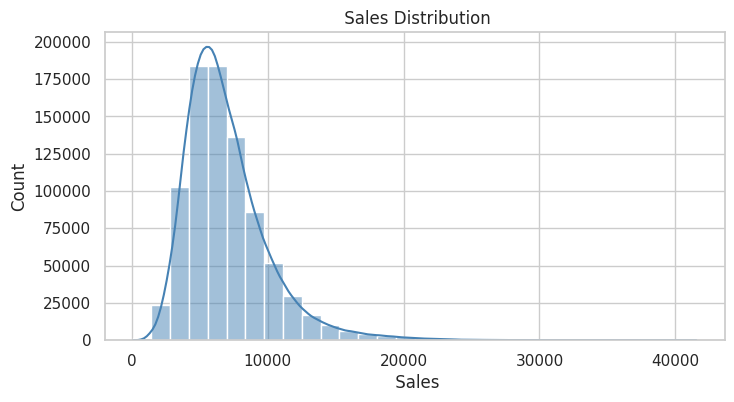

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Припустимо, y_pred — це ваші спрогнозовані значення
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Побудова розподілу
sns.histplot(open_train['Sales'], kde=True, color="steelblue", bins=30)

plt.title(' Sales Distribution')
plt.xlabel(' Sales')
# plt.ylabel('Частота')
plt.show()

Розподіл справжніх даних

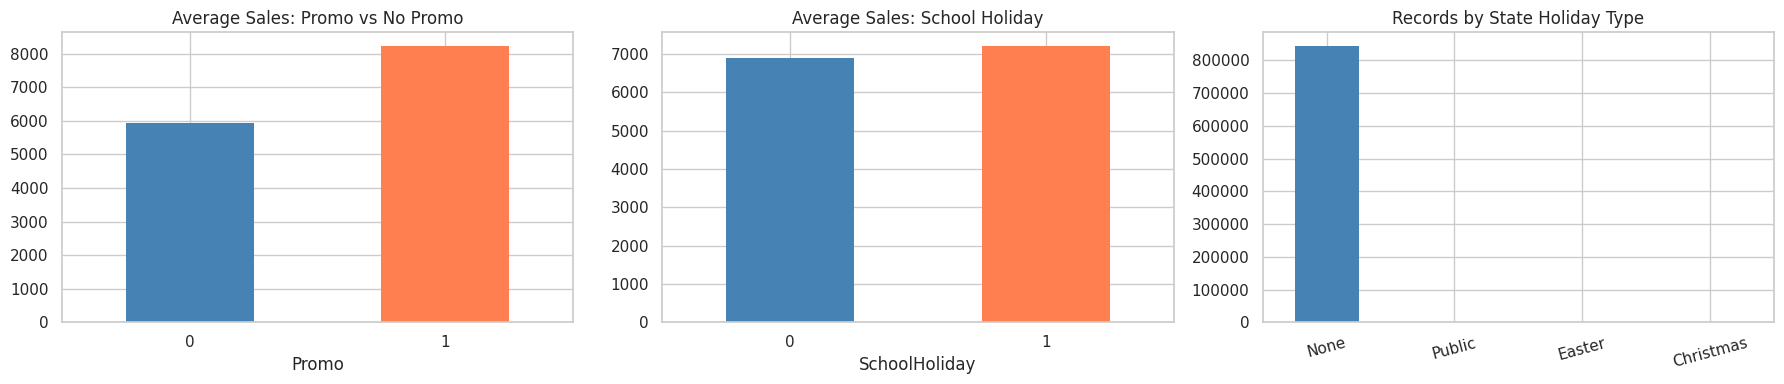

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

open_train.groupby('Promo')['Sales'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='none'
)
axes[0].set_title('Average Sales: Promo vs No Promo')
axes[0].set_xlabel('Promo')
axes[0].tick_params(axis='x', rotation=0)

open_train.groupby('SchoolHoliday')['Sales'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='none'
)
axes[1].set_title('Average Sales: School Holiday')
axes[1].set_xlabel('SchoolHoliday')
axes[1].tick_params(axis='x', rotation=0)

sh_sales = open_train.copy()
sh_sales['StateHoliday'] = sh_sales['StateHoliday'].replace(
    {'0': 'None', 0: 'None', 'a': 'Public', 'b': 'Easter', 'c': 'Christmas'}
)
sh_sales['StateHoliday'].value_counts().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='none'
)
axes[2].set_title('Records by State Holiday Type')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Акції є найбільш контрольованим фактором обсягу продажів. Магазини, які проводять акції, демонструють стабільне зростання середньодобових продажів — очікується, що ця змінна буде однією з головних характеристик у деревоподібних моделях. Шкільні канікули демонструють помірний позитивний вплив, тоді як державні свята рідко зустрічаються в наборі даних і мають обмежену прогностичну вагу для загальної моделі.

In [9]:
print('=== StoreType distribution ===')
print(store['StoreType'].value_counts())
print()
print('=== Assortment distribution ===')
print(store['Assortment'].value_counts())
print()
print('=== CompetitionDistance — statistics ===')
print(store['CompetitionDistance'].describe())

=== StoreType distribution ===
StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

=== Assortment distribution ===
Assortment
a    593
c    513
b      9
Name: count, dtype: int64

=== CompetitionDistance — statistics ===
count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64


Тип магазину «a» домінує в мережі (54%), тоді як тип «b» має лише 17 одиниць — модель матиме обмежені дані для вивчення шаблонів типу «b». Медіанна дистанція конкуренції становить 2325 м з високою дисперсією (стандартне відхилення 7663 м), що робить цю функцію значущою безперервною після введення 3 відсутніх значень.

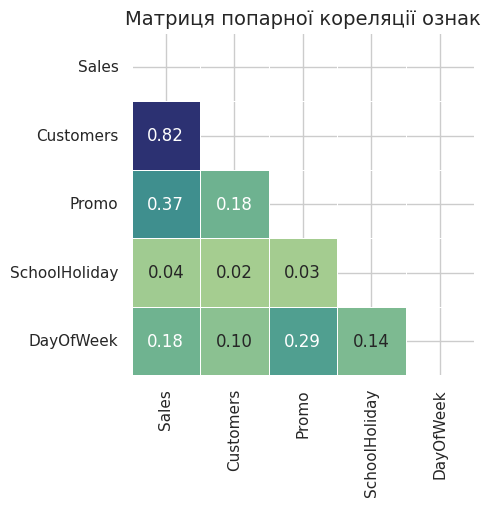

In [10]:
numeric_cols = ['Sales', 'Customers', 'Promo', 'SchoolHoliday', 'DayOfWeek']


mtx = open_train[numeric_cols].corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(5, 6))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Показник кореляції кількості клієнтів( 0,82) найбільше впливає на продажі, але його не можна використовувати безпосередньо — у реальному сценарії прогнозування, майбутня кількість клієнтів невідома. Його включення означатиме витік даних. Натомість, як показник без витоків, буде використано середнє значення кількості клієнтів на магазин і день тижня.

Генерація Ознак 

In [11]:
df = train[(train['Open'] == 1) & (train['Sales'] > 0)].copy()
print(f'Records after filter (Open=1, Sales>0): {df.shape[0]:,}')

df = df.merge(store, on='Store', how='left')
print(f'Shape after merge with store          : {df.shape}')

Records after filter (Open=1, Sales>0): 844,338
Shape after merge with store          : (844338, 18)


In [12]:
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

Визначено дні коли магазин був відчинений та були успішні продажі  по конкретним рокам,місяцям, дням та дням тижня  замість повних дат 


In [13]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(
    df['CompetitionDistance'].max() * 2
)

df['CompetitionOpenSinceYear']  = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)

df['CompetitionOpenMonths'] = np.where(
    df['CompetitionOpenSinceYear'] > 0,
    (df['Year'] - df['CompetitionOpenSinceYear']) * 12 +
    (df['Month'] - df['CompetitionOpenSinceMonth']),
    0
)
df['CompetitionOpenMonths'] = df['CompetitionOpenMonths'].clip(lower=0)

Пропущені значення відстаней до конкурента df['CompetitionDistance'] заповнювалася максимальним помноженим на два що б показати що конкурент є дуже далеко.  Пропущені значення конукрент відкрився з початку року та початку місяця ставимо нуль. Це дозволяє нам надалі виконувати математичні операції з цими колонками, не отримуючи помилок. Створилася метрика скільки працює конкурент відносно поточної дати продажу

In [14]:
month_to_name = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

df['PromoInterval'] = df['PromoInterval'].fillna('')
df['MonthName']     = df['Month'].map(month_to_name)

df['IsPromo2Active'] = (
    (df['Promo2'] == 1) &
    df.apply(lambda r: r['MonthName'] in r['PromoInterval'], axis=1)
).astype(int)

df.drop(columns=['MonthName'], inplace=True)

 Перетворено числові місяці (1, 2, 3) у скорочені назви ('Jan', 'Feb', 'Mar'). Це потрібно, тому що в колонці PromoInterval місяці записані текстом (наприклад, "Jan,Apr,Jul,Oct")  ,.fillna(''): Замінилися порожні значення (NaN) у графіку акцій на порожні рядки. Це запобігає помилкам при подальшій перевірці тексту. 
Promo2 — це не просто акція, вона працює за циклічним графіком. 
Щоб акція вважалася активною (1), мають виконуватися дві умови одночасно:
df['Promo2'] == 1: Магазин взагалі бере участь у цій програмі.
r['MonthName'] in r['PromoInterval']: Поточний місяць входить у графік акції цього магазину.
Наприклад: Якщо зараз May (травень), а у магазину акційний інтервал "Feb,May,Aug,Nov", то умова поверне True.
Результат перетворювався на ціле число (0 або 1) за допомогою .astype(int).
Виділена тимчасова колонка MonthName, оскільки вона була потрібна лише як допоміжний інструмент для розрахунку. Це допомагає тримати датасет "чистим" і економити пам'ять. 


In [15]:
le = LabelEncoder()
for col in ['StoreType', 'Assortment']:
    df[col] = le.fit_transform(df[col].astype(str))

state_holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
df['StateHoliday'] = df['StateHoliday'].map(state_holiday_map).fillna(0).astype(int)

print('Encoding complete.')

Encoding complete.


Декодуються типи магазинів асортимент та державні свята.


In [16]:
# Temporal split — train on older data, validate on most recent period
split_date = '2015-06-01'

train_fold = df[df['Date'] < split_date].copy()
val_fold   = df[df['Date'] >= split_date].copy()

# Target encoding: replace Store ID with its historical mean sales (train only)
store_mean_sales = train_fold.groupby('Store')['Sales'].mean().rename('StoreMeanSales')

train_fold = train_fold.merge(store_mean_sales, on='Store', how='left')
val_fold   = val_fold.merge(store_mean_sales, on='Store', how='left')

global_mean = train_fold['Sales'].mean()
val_fold['StoreMeanSales'] = val_fold['StoreMeanSales'].fillna(global_mean)

print('Target encoding — StoreMeanSales: done')
print(f'Nulls in train: {train_fold["StoreMeanSales"].isnull().sum()} | Nulls in val: {val_fold["StoreMeanSales"].isnull().sum()}')


Target encoding — StoreMeanSales: done
Nulls in train: 0 | Nulls in val: 0


Тренувалні та тестові дані розбиваютья за окремою контрольною датою split_date = '2015-06-01'. Визначились дані середніх історичних продажів кожного магазину  store_mean_sales , які об’єднуються з тренувальними та тестовими данними . Пропуски заповнились середніми даними продажів. Вивилась сума пропущених значень в тренувальній та тестовій вибірці.


In [17]:
# Leakage-free customer proxy: historical average customers per Store x DayOfWeek
cust_mean = (
    train_fold.groupby(['Store', 'DayOfWeek'])['Customers']
    .mean()
    .rename('AvgCustomers')
    .reset_index()
)

train_fold = train_fold.merge(cust_mean, on=['Store', 'DayOfWeek'], how='left')
val_fold   = val_fold.merge(cust_mean, on=['Store', 'DayOfWeek'], how='left')

global_cust_mean = train_fold['Customers'].mean()
train_fold['AvgCustomers'] = train_fold['AvgCustomers'].fillna(global_cust_mean)
val_fold['AvgCustomers']   = val_fold['AvgCustomers'].fillna(global_cust_mean)

print('Feature AvgCustomers: done')
print(f'Nulls in train: {train_fold["AvgCustomers"].isnull().sum()} | Nulls in val: {val_fold["AvgCustomers"].isnull().sum()}')

Feature AvgCustomers: done
Nulls in train: 0 | Nulls in val: 0


Далі сформована ознаку AvgCustomers (середня кількість покупців). Вона працює за тим самим принципом, що й попередній StoreMeanSales, але є більш деталізованою. Цей код рахує скільки в середньому покупців приходить у Магазин №1 саме по понеділках, скільки по вівторках і т.д.. Об’єдналася з тренувальним та тестовим набором, заповнились пропуски середнім  значенням


In [18]:
features = [
    'DayOfWeek', 'Promo', 'SchoolHoliday', 'StateHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenMonths',
    'Promo2', 'IsPromo2Active', 'Year', 'Month', 'Day', 'WeekOfYear',
    'StoreMeanSales', 'AvgCustomers'
]
target = 'Sales'

missing_feat = [f for f in features if f not in train_fold.columns]
if missing_feat:
    raise ValueError(f'Missing features: {missing_feat}')

print(f'Total features  : {len(features)}')
print(f'Nulls — train   : {train_fold[features].isnull().sum().sum()}')
print(f'Nulls — val     : {val_fold[features].isnull().sum().sum()}')

X_train, y_train = train_fold[features], train_fold[target]
X_val,   y_val   = val_fold[features],   val_fold[target]

print(f'\nTrain set : {X_train.shape}')
print(f'Val set   : {X_val.shape}')

Total features  : 16
Nulls — train   : 0
Nulls — val     : 0

Train set : (785727, 16)
Val set   : (58611, 16)


Виділились ознаки на яких модель буде навчатися та цільову змінну . Перевірилась кількість наявних ознак на пропуски. Розподілились дані на : 
X_train / y_train: На цих даних модель буде вчитися знаходити зв'язки.
X_val / y_val: Модель ніколи не бачила цих відповідей під час навчання, тому на них перевірилась  реальна точність.Визначився розмір даних 

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

from sklearn.feature_selection import mutual_info_regression

In [21]:
X = X_train
y = y_train

In [22]:
mi_scores = mutual_info_regression(
    X, y,
    random_state=42)

mi_scores = (pd.Series(
    mi_scores,
    name='MI Scores',
    index=X.columns)
    .sort_values())

mi_scores.sample(5)

DayOfWeek                0.042692
StoreType                0.016026
IsPromo2Active           0.002737
CompetitionOpenMonths    0.010265
Year                     0.003225
Name: MI Scores, dtype: float64

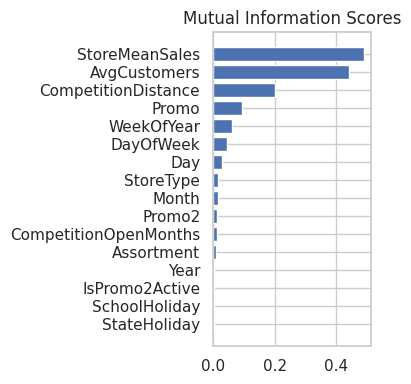

In [23]:
plt.figure(figsize=(4, 4))
plt.barh(np.arange(len(mi_scores)), mi_scores)
plt.yticks(np.arange(len(mi_scores)), mi_scores.index)
plt.title('Mutual Information Scores')
plt.tight_layout()
plt.show()

За важливістью ознак вагомими є ‘StoreMeanSales’, ‘AvgCustomers’, ‘CompetitionDistance’. Ознаки ‘SchoolHoliday’, ‘StateHoliday’ мають найменший вплив на цільову змінну.


In [24]:
results = []

def evaluate(name: str, y_true, y_pred) -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    # print(f'{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')
    print(f'{name:<25s} | RMSE: {rmse:>10,.2f} | MAE: {mae:>10,.2f} | R2: {r2:.2f},| MAPE: {mape:.2f}%')
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2': round(r2, 4),'MAPE': round(mape, 4) }

Створився пустий масив results = [] куди додано результати функції

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = np.clip(lr.predict(X_val), 0, None)
results.append(evaluate('Linear Regression', y_val, lr_pred))

Linear Regression         | RMSE:   1,404.81 | MAE:   1,015.63 | R2: 0.80,| MAPE: 15.47%


In [26]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
results.append(evaluate('Random Forest', y_val, rf_pred))

Random Forest             | RMSE:   1,215.40 | MAE:     853.73 | R2: 0.85,| MAPE: 12.12%


In [27]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_val)
results.append(evaluate('XGBoost', y_val, xgb_pred))

XGBoost                   | RMSE:   1,015.72 | MAE:     734.80 | R2: 0.89,| MAPE: 11.35%


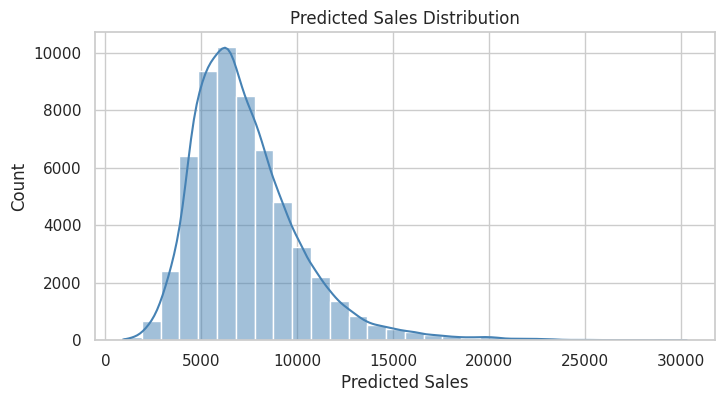

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Припустимо, y_pred — це ваші спрогнозовані значення
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Побудова розподілу
sns.histplot(xgb_pred, kde=True, color="steelblue", bins=30)

plt.title('Predicted Sales Distribution')
plt.xlabel('Predicted Sales')
# plt.ylabel('Частота')
plt.show()

# fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# xgb_pred.hist(bins=60, ax=axes[0], color='steelblue', edgecolor='none')
# axes[0].set_title('Predicted Sales Distribution')
# axes[0].set_xlabel('Sales')


Якщо порівняти розподіли справжніх та прогнозованих даних моделі XGBRegressor то значних змін не спостерігається.

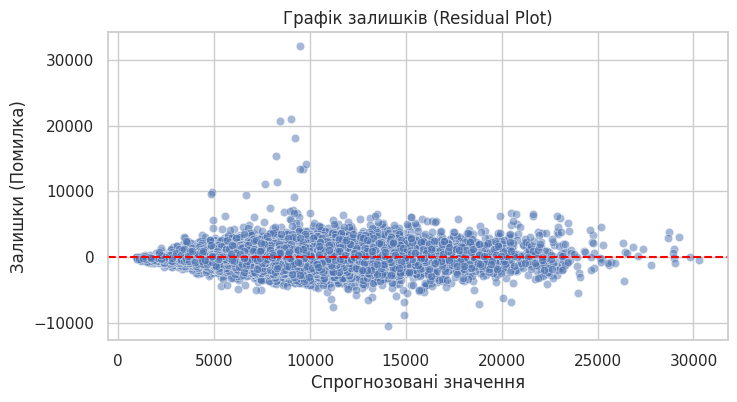

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Обчислюємо залишки
residuals = y_val - xgb_pred

plt.figure(figsize=(8, 4))
sns.scatterplot(x=xgb_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')  # Лінія ідеального прогнозу

plt.title('Графік залишків (Residual Plot)')
plt.xlabel('Спрогнозовані значення')
plt.ylabel('Залишки (Помилка)')
plt.show()

Як видно з рисунку  розкид залишків не є критичним. Максимальні зачення розподілу 10 000 одиниць . Залишки в 4000-5000 є цілком прийнятними.

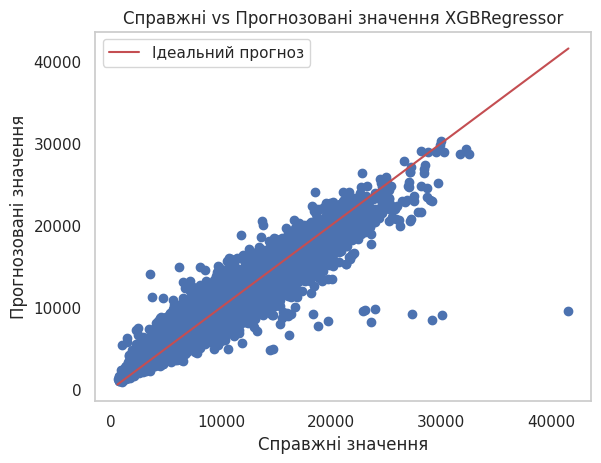

In [30]:
plt.figure()

plt.scatter(y_val, xgb_pred)

# Лінія ідеального прогнозу
min_val = min(y_val.min(), xgb_pred.min())
max_val = max(y_val.max(), xgb_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r-', label='Ідеальний прогноз')

plt.xlabel('Справжні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Справжні vs Прогнозовані значення XGBRegressor')
plt.grid()
plt.legend()

plt.show()

Прогнозовані дані близькі до справжніх.

In [31]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_val)
results.append(evaluate('LightGBM', y_val, lgb_pred))

LightGBM                  | RMSE:   1,065.12 | MAE:     770.54 | R2: 0.88,| MAPE: 11.89%


Результати оцінки моделей

In [32]:
results_df = pd.DataFrame(results).sort_values('R2').reset_index(drop=True)
print('=== Model Comparison (sorted by R2) ===')
print(results_df.to_string(index=False))

=== Model Comparison (sorted by R2) ===
            Model    RMSE     MAE     R2    MAPE
Linear Regression 1404.81 1015.63 0.7961 15.4694
    Random Forest 1215.40  853.73 0.8474 12.1199
         LightGBM 1065.12  770.54 0.8828 11.8915
          XGBoost 1015.72  734.80 0.8934 11.3459


Як видно з результатів дослідження описаних в таблиці  найкращі показники точності має модель XGBRegressor з коефіцієнтом детермінації 0.89 та середньою абсолютною відсотковою помилкою 11.34%. Дуже близькі показники має модель LGBMRegressor коефіцієнт детермінації 0.88 та середньою абсолютною відсотковою помилкою 11.89%. Третє місце зайняла модель  Random Forest Regressor де коефіцієнт детермінації 0.84 та середня абсолютна квадратична помилка 12.11% . Найгірші результати показала модель  Linear Regression з коефіцієнтом детермінації 0.79 та середньою абсолютною відсотковою помилкою 15.46%
